<a href="https://colab.research.google.com/github/sarnika09-cell/Plant-Disease-Detection-using-CNN/blob/main/plant_DiseaseDetection_using_CNN_2866.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Untitled3.ipynb', 'PlantVillage', 'IMG_2204 (1).jpeg', 'IMG_2204.jpeg', 'IMG_2241.jpeg', 'Untitled presentation (5).gslides', ' lang1012', 'Untitled presentation (4).gslides', 'Untitled presentation (3).gslides', 'paw paw academy.gsite', 'Untitled presentation (2).gslides', 'paw paw.gsite', 'Copy of Collaborative Work (1).gdoc', 'Untitled0.ipynb', 'Untitled1.ipynb', 'Untitled2.ipynb', 'IMG_8237.png', '_python - Sheet1 (1).csv', 'sar123', 'Colab Notebooks', ' Python_files', ' 2023002866.ipynb', 'Untitled document (16).gdoc', 'Untitled document (15).gdoc', ' Print 1.JPG', ' Print 2.JPG', 'Untitled document (14).gdoc', 'Untitled document (13).gdoc', ' CEW 2866.docx', 'Dt.gdoc', 'Dt 6.gdoc', ' Dt', 'First row.gdoc', 'Third row.gdoc', 'Copy of First row.docx', 'First row.docx', 'Admit Card.pdf', 'Third row.docx', 'Untitled document (1).docx', 'MVP 2 new (1).gdoc', ' MVP 1 new.gdoc', 'Untitled document (12).gdoc', 'MVP 2 new.gdoc', ' MVP 3.docx', 'Data structures lab record.gdoc', 'Untitle

In [ ]:
data_dir = "/content/drive/MyDrive/PlantVillage"

In [ ]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 20685 files belonging to 15 classes.
Using 16548 files for training.


In [ ]:
import os

for root, dirs, files in os.walk(data_dir):
    print(root)
    break

/content/drive/MyDrive/PlantVillage


In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'sample_data']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

data_dir = "/content/drive/MyDrive/PlantVillage"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 20685 files belonging to 15 classes.
Using 16548 files for training.
Found 20685 files belonging to 15 classes.
Using 4137 files for validation.


In [ ]:
model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(train_data.class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(train_data, validation_data=val_data, epochs=5)

Epoch 1/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.8908 - loss: 0.3222 - val_accuracy: 0.8733 - val_loss: 0.3667
Epoch 2/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 0.9298 - loss: 0.2064 - val_accuracy: 0.8975 - val_loss: 0.3001
Epoch 3/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 639s 1s/step - accuracy: 0.9499 - loss: 0.1437 - val_accuracy: 0.9002 - val_loss: 0.3144
Epoch 4/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 637s 1s/step - accuracy: 0.9634 - loss: 0.1086 - val_accuracy: 0.8779 - val_loss: 0.4321
Epoch 5/5
518/518 ━━━━━━━━━━━━━━━━━━━━ 611s 1s/step - accuracy: 0.9755 - loss: 0.0729 - val_accuracy: 0.9132 - val_loss: 0.3268


In [ ]:
model.save("/content/drive/MyDrive/plant_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/plant_model.h5")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 0a0dbf1f-1131-496f-b337-169ec6693e6f___NREC_B.Spot 9241.JPG to 0a0dbf1f-1131-496f-b337-169ec6693e6f___NREC_B.Spot 9241.JPG


In [ ]:
img_path = "0a0dbf1f-1131-496f-b337-169ec6693e6f___NREC_B.Spot 9241.JPG"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


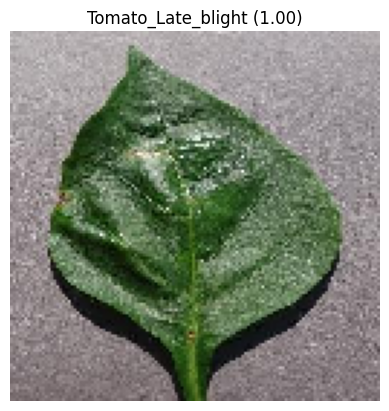

Prediction: Tomato_Late_blight
Confidence: 1.0


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)

# Preprocess
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Get class
predicted_class = train_data.class_names[np.argmax(prediction)]
confidence = np.max(prediction)

# Show result
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()

print("Prediction:", predicted_class)
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 936ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 586ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/

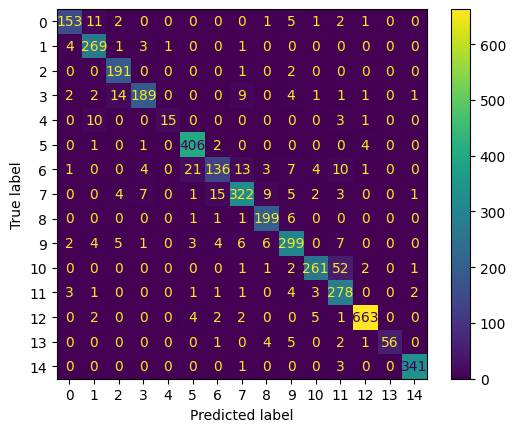

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true = []
y_pred = []

for images, labels in val_data:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()